<img src="https://github.com/Ch3ddarr/DSB-Unit-02/blob/main/03%20-%20Data%20Visualisation/assets/ga-logo.png?raw=1" style="float: left; margin: 20px; height: 55px">

# Guided Practice: Explore Python Data Visualization

---

In this guided practice lab you will use `pandas`, `matplotlib`, and `seaborn` to create simple plots.

We'll cover plotting line plots, scatter plots, bar plots, and histograms, and how to manipulate the style of your plots with `matplotlib`.

## Learning Objectives

- **Practise** using different types of plots
- **Use** pandas methods for plotting
- **Create** line plots, bar plots, histograms, and box plots
- **Know** when to use `seaborn` or `matplotlib`

## Lesson Guide

- a) Line Plots
- b) Bar Plots
- c) Histograms
    - Grouped Histograms
- d) Box Plots
    - Grouped Box Plots
- e) Scatter Plots
- f) Using `seaborn`
- g) A brief overview of `matplotlib` (Figures, Subplots, and Axes)
- h) Additional Topics
- Summary

### Introduction

In this notebook, we will introduce how plotting works in pandas and Matplotlib. **It is important to know that pandas uses Matplotlib behind the scenes to make plots.**

As you get to know both `.plot()` in pandas and the Matplotlib library as well, you will notice that pandas plotting methods often use similar parameter names as Matplotlib methods.

Further, you can use Matplotlib functions in combination with pandas methods to alter the plots after drawing them. For example, you can use Matplotlib's `xlabel` and `title` functions to label the plot's x-axis and title, respectively, after it is drawn.

As we explore different types of plots, notice:

1. Different types of plots are drawn very similarly -- they even tend to share parameter names.
2. In pandas, calling `plot()` on a `DataFrame` is different than calling it on a `Series`. Although the methods are both named `plot`, they may take different parameters.

Toward the end of the lab, we will show some motivational plots using Seaborn, a popular statistics plotting library, as well as go more in-depth about how Matplotlib works.

### pandas Plotting Documentation

[Link to Documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

### Create fake data for examples

In [2]:
np.random.randn(10, 4)

array([[-0.00309086,  0.22320397, -0.82152764, -0.50248961],
       [ 0.8550976 ,  0.08086853,  0.04637022,  0.2437856 ],
       [ 1.16409669, -2.25150801,  0.00620256, -0.02349113],
       [-0.25583171, -1.44336516,  0.89380754,  1.32533558],
       [ 0.69522091, -0.31453901,  1.47293685, -0.16207188],
       [ 0.78279555, -0.02618329, -1.25761126, -0.74265641],
       [ 0.26574391, -0.29309012,  1.20464611,  0.27476428],
       [-0.66010434, -0.48338649, -0.2034807 ,  1.90501936],
       [ 0.49481694,  0.33721905,  1.30795879, -0.94067784],
       [ 0.2647295 ,  0.7648049 , -0.06969617,  1.07651251]])

In [3]:
df = pd.DataFrame(np.random.randn(10, 4),
                  columns=['col1', 'col2', 'col3', 'col4'],
                  index=['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j'])

df

,col1,col2,col3,col4
a,-1.593523,0.424750,-1.468864,-1.490365
b,0.864435,1.020270,-0.491846,0.088245
c,0.057337,1.051145,-0.409309,0.103188
d,-0.054367,-2.346387,-0.120753,1.996821
e,-1.112318,-0.808297,0.741045,0.266204
f,-0.667920,0.210978,0.517567,0.415181
g,0.087705,-0.221782,0.369568,0.548043
h,-1.566363,-0.369984,0.936378,-1.816152
i,-1.181950,-1.199401,-2.680451,0.175596
j,-0.356557,-0.133507,0.679419,0.240343


### Load in other data sets for visualization examples

The House Sales in King County (USA) housing data that we will be using can be found [here](https://www.kaggle.com/harlfoxem/housesalesprediction). Take a few minutes to familiarise yourself the dataset.

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harlfoxem/housesalesprediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'housesalesprediction' dataset.
Path to dataset files: /kaggle/input/housesalesprediction


In [5]:
# Read in the ufo data and add 2 columns with time data
ufo = pd.read_csv('https://raw.githubusercontent.com/Ch3ddarr/DSB-Unit-02/refs/heads/main/mywork/03%20-%20Data%20Visualisation/practice/data/ufo.csv')
ufo['Time'] = pd.to_datetime(ufo.Time)
ufo['Year'] = ufo.Time.dt.year

# Read in the drinks data
drink_cols = ['country', 'beer', 'spirit', 'wine', 'liters', 'continent']
url = 'https://raw.githubusercontent.com/Ch3ddarr/DSB-Unit-02/refs/heads/main/mywork/03%20-%20Data%20Visualisation/practice/data/drinks.csv'
drinks = pd.read_csv(url, header=0, names=drink_cols, na_filter=False)

# Read in the housing data
housing_csv = '/kaggle/input/housesalesprediction/kc_house_data.csv'
housing = pd.read_csv(housing_csv)

In [6]:
ufo.head()

,City,Colors Reported,Shape Reported,State,Time,Year
0,Ithaca,NaN,TRIANGLE,NY,1930-06-01 22:00:00,1930
1,Willingboro,NaN,OTHER,NJ,1930-06-30 20:00:00,1930
2,Holyoke,NaN,OVAL,CO,1931-02-15 14:00:00,1931
3,Abilene,NaN,DISK,KS,1931-06-01 13:00:00,1931
4,New York Worlds Fair,NaN,LIGHT,NY,1933-04-18 19:00:00,1933


In [7]:
ufo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80543 entries, 0 to 80542
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   City             80492 non-null  object        
 1   Colors Reported  17034 non-null  object        
 2   Shape Reported   72141 non-null  object        
 3   State            80543 non-null  object        
 4   Time             80543 non-null  datetime64[ns]
 5   Year             80543 non-null  int32         
dtypes: datetime64[ns](1), int32(1), object(4)
memory usage: 3.4+ MB


In [8]:
drinks.head()

,country,beer,spirit,wine,liters,continent
0,Afghanistan,0,0,0,0.0,AS
1,Albania,89,132,54,4.9,EU
2,Algeria,25,0,14,0.7,AF
3,Andorra,245,138,312,12.4,EU
4,Angola,217,57,45,5.9,AF


In [9]:
drinks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    193 non-null    object 
 1   beer       193 non-null    int64  
 2   spirit     193 non-null    int64  
 3   wine       193 non-null    int64  
 4   liters     193 non-null    float64
 5   continent  193 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 9.2+ KB


In [10]:
housing.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [11]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

### <font style='color: orange'>What is the next thing we should do?</font>

### Choosing the right type of visualization

The choice of visualization should depend what you are trying to show. Here is a helpful flowchart that you can use to determine the best type of visualizations.

![Chart Suggestions](https://github.com/Ch3ddarr/DSB-Unit-02/blob/main/03%20-%20Data%20Visualisation/assets/chart_suggestions.png?raw=1)

Another great resource is the [FT's Visual Vocabulary](http://ft-interactive.github.io/visual-vocabulary/)

# <font style='color: blue'>a) Line plots: Show the trend of a numerical variable over time</font>
---

- **Objective:** Use pandas methods for plotting.
- **Objective:** Create line plots, bar plots, histograms, and box plots.

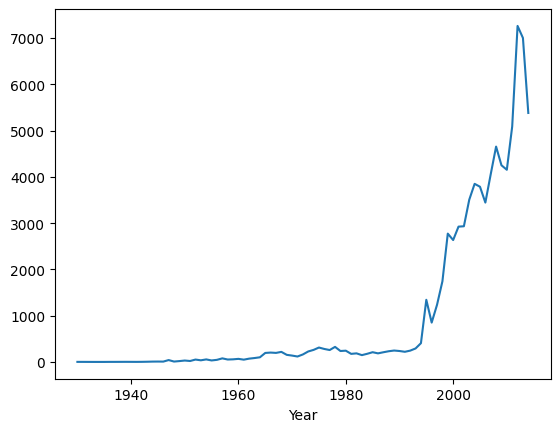

In [12]:
# Count the number of ufo reports each year (and sort by year).

ufo['Year'].value_counts().sort_index().plot();

<Axes: xlabel='Year'>

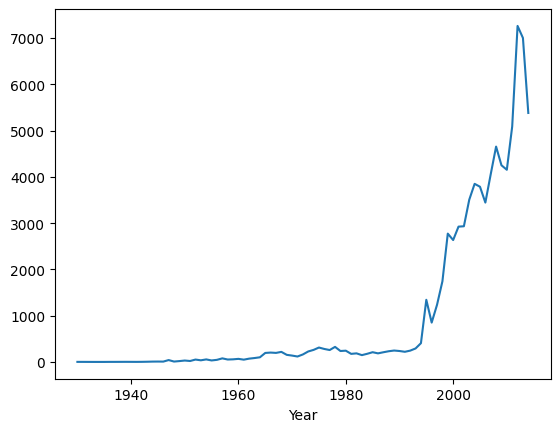

In [13]:
sightings = ufo['Year'].value_counts().sort_index()

sightings.plot()

In [14]:
ufo['Time'].max()

Timestamp('2014-09-05 05:30:00')

<Axes: xlabel='continent'>

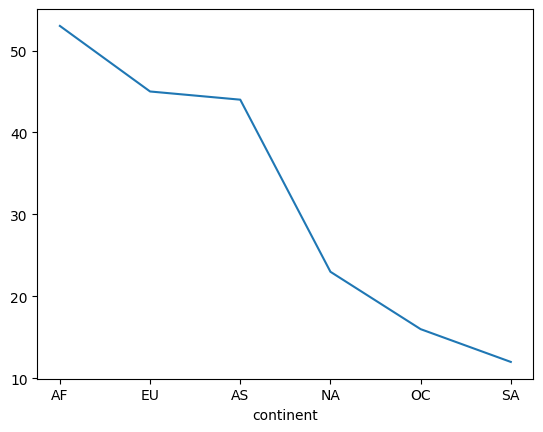

In [15]:
# Let's have a look at the drinks data and plot the countries per continent

# We'll see a COMMON MISTAKE: Don't use a line plot
# when the x-axis cannot be ordered sensically!

# For example, ordering by continent below shows a trend where no exists ...
#    ...it would be just as valid to plot the continents in any order.

# So, a line plot is the wrong type of plot for this data.
# Always think about what you're plotting and if it makes sense.

drinks['continent'].value_counts().plot()

**Important:** A line plot is the wrong type of plot for this data. Any set of countries can be rearranged misleadingly to illustrate a negative trend, as we did here. Due to this, it would be more appropriate to represent this data using a bar plot, which does not imply a trend based on order.

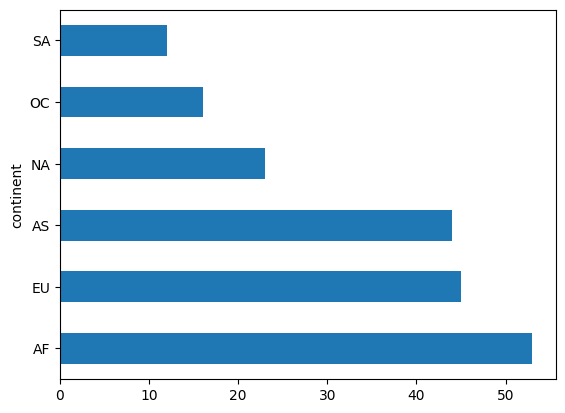

In [16]:
# Plot the same data as a (horizontal) bar plot -- a much better choice!


drinks['continent'].value_counts().plot(kind='barh');

### Line Plot with the dummy `DataFrame`

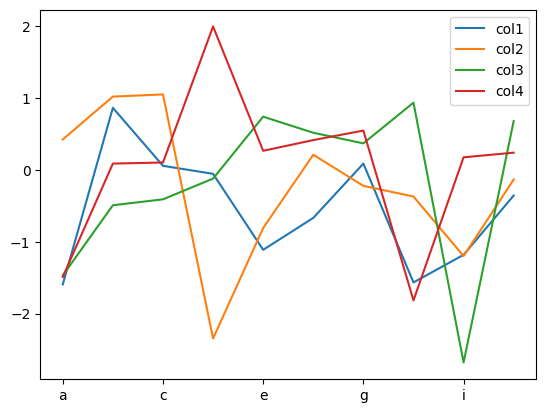

In [17]:
df.plot();

### How to change the size of a plot

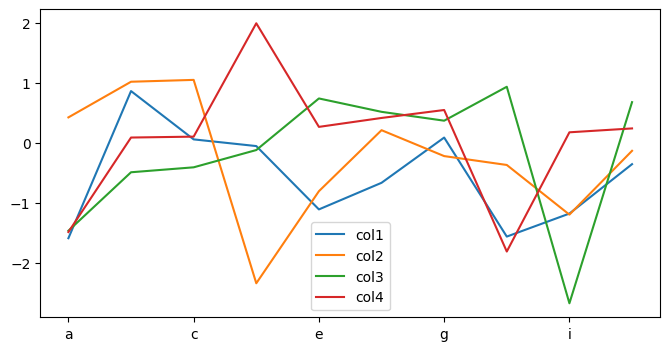

In [20]:
# Technically the figsize is 15 "inches" (width) by 8 "inches" (height)
# The figure is specified in inches for printing -- you set a dpi (dots/pixels per inch) elsewhere

# width, height


df.plot(figsize=(8,4), fontsize=10);

### How to change the color of a plot

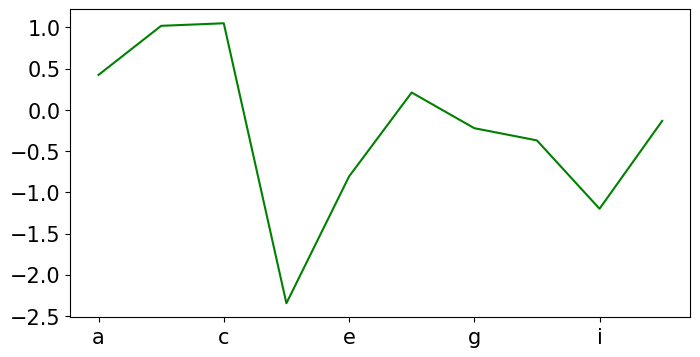

In [21]:
# as well as naming colors, you can also use Hex values (#008000) and RBG values (0,1,0,1)

df['col2'].plot(color='green',figsize=(8,4), fontsize=15);

### How to change the style of individual lines

When using just `.plot()`, you can use MATLAB syntax:

Solid (`-`)
Dashed (`--`)
Dotted (`:`)
Dashdot (`-.`)

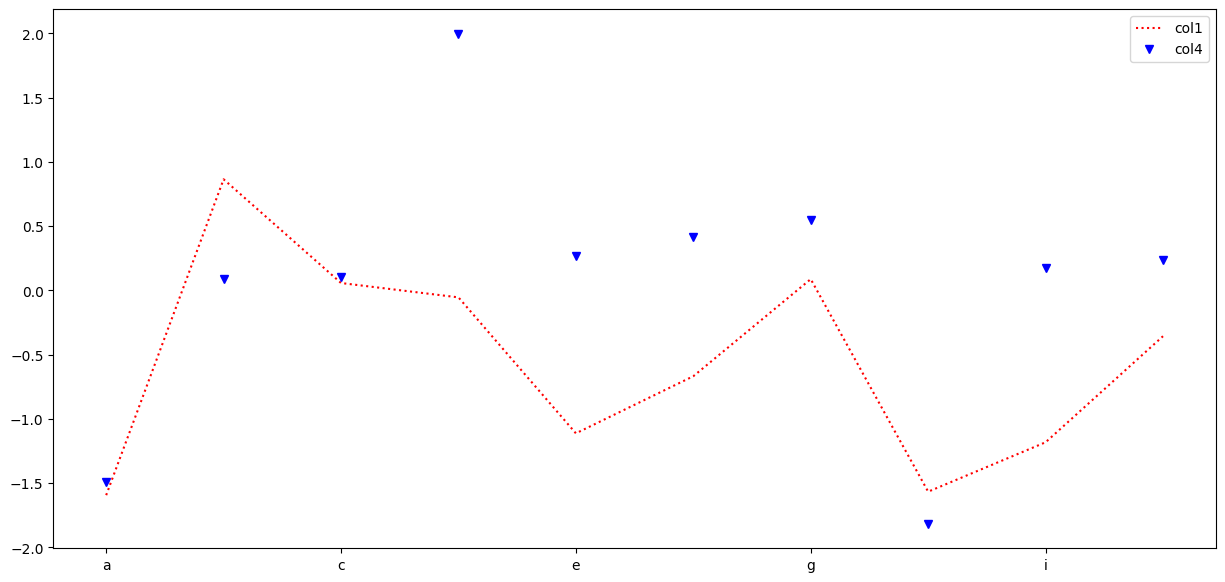

In [22]:
# : - dotted line, v - triangle_down
# r - red, b - blue

df[['col1', 'col4']].plot(figsize=(15,7), style={'col1': ':r', 'col4': 'vb'}, xticks=[0,2,4,6,8]);

### <font style='color: green'>Challenge: Use the housing data to create a line plot of `sqft_above` and `sqft_basement` in the housing data.</font>

- For `sqft_above`, use a solid green line. For `sqft_basement`, use a blue dashed line
- Change the figure size to a width of 12 and height of 8
- Change the scale for x axis (`xlim`) to 0-200, and for the y axis (`ylim`) to 0-6000
- Change the line width (`lw`) to 0.5
- Change the style sheet to something else.  Hint: you can see which styles are available by running `plt.style.available`.  [This](https://tonysyu.github.io/raw_content/matplotlib-style-gallery/gallery.html) is what they look like (though note the names for the seaborn ones should be as per the command)

<Axes: >

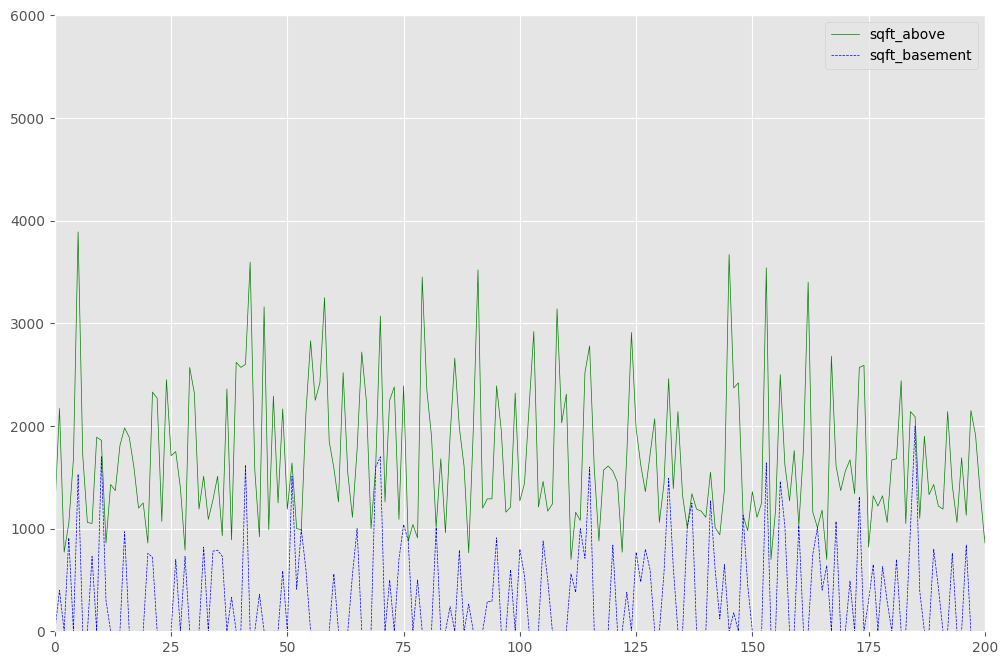

In [31]:
plt.style.use('ggplot')
housing[['sqft_above', 'sqft_basement']].plot(
    style={'sqft_above':'-g', 'sqft_basement':'--b'},
    figsize=(12,8),
    xlim=(0,200),
    ylim=(0,6000),
    lw=0.5
    )

# <font style='color: blue'>b) Bar Plots: Show a numerical comparison across different categories</font>
---

In [32]:
# Count the number of countries in each continent

drinks['continent'].value_counts()

,count
continent,
AF,53
EU,45
AS,44
NA,23
OC,16
SA,12


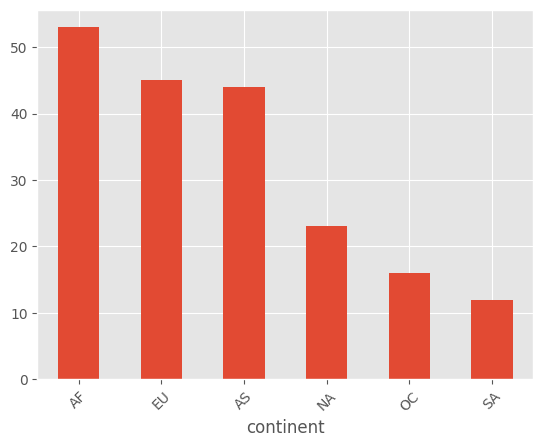

In [33]:
# Compare with bar plot.  The rot parameter sets the rotation of the x-axis labels

countries = drinks['continent'].value_counts()

countries.plot(kind='bar', rot=45);

### Stacked works on horizontal bar charts.

In [34]:
df

,col1,col2,col3,col4
a,-1.593523,0.424750,-1.468864,-1.490365
b,0.864435,1.020270,-0.491846,0.088245
c,0.057337,1.051145,-0.409309,0.103188
d,-0.054367,-2.346387,-0.120753,1.996821
e,-1.112318,-0.808297,0.741045,0.266204
f,-0.667920,0.210978,0.517567,0.415181
g,0.087705,-0.221782,0.369568,0.548043
h,-1.566363,-0.369984,0.936378,-1.816152
i,-1.181950,-1.199401,-2.680451,0.175596
j,-0.356557,-0.133507,0.679419,0.240343


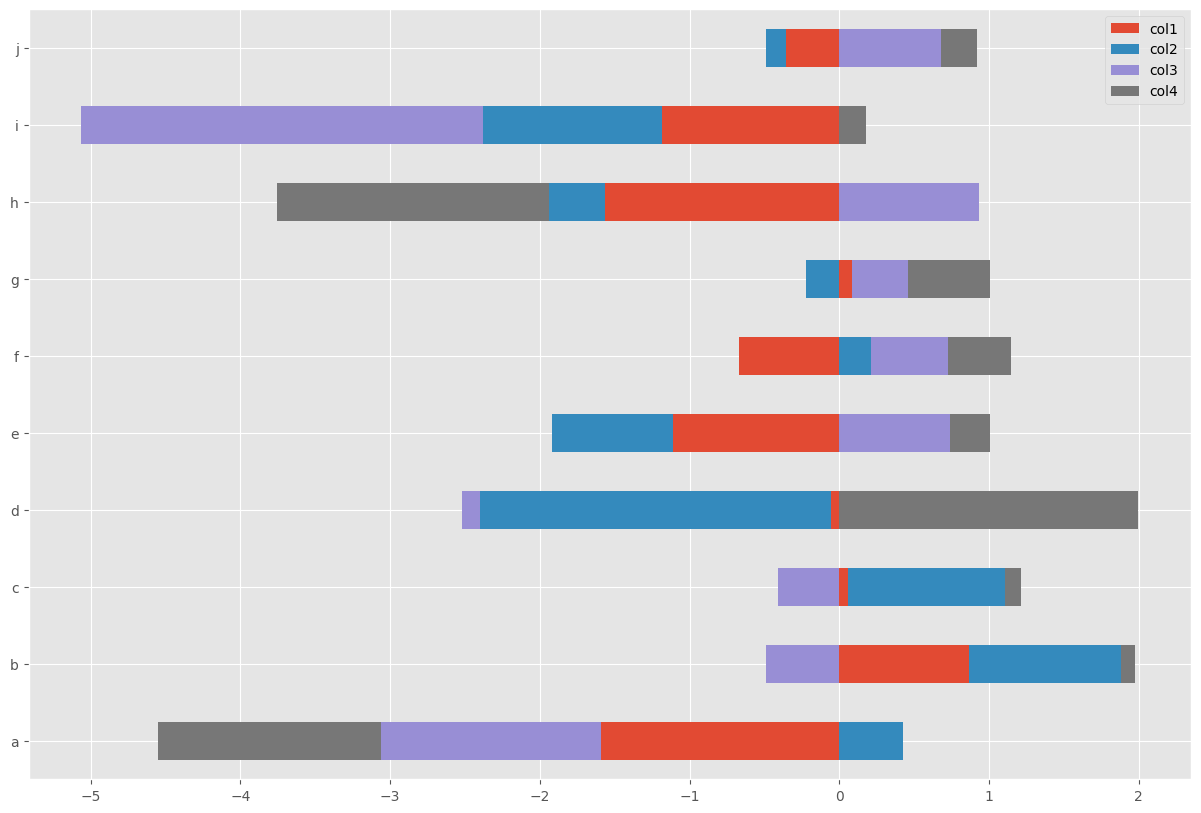

In [35]:
df.plot(kind='barh', figsize=(15,10), stacked=True);

# <font style='color: blue'>c) Histograms: Show the distribution of a numerical variable</font>
---


In [36]:
# Sort the beer column and mentally split it into three groups

drinks['beer'].sort_values().values

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   1,   1,   1,   1,   2,   3,   5,   5,   5,   5,   5,
         6,   6,   6,   6,   8,   8,   8,   9,   9,   9,   9,  12,  13,
        15,  15,  16,  16,  17,  18,  19,  19,  20,  20,  21,  21,  21,
        21,  22,  23,  25,  25,  25,  25,  26,  28,  31,  31,  31,  31,
        32,  32,  34,  36,  36,  36,  37,  42,  42,  43,  44,  45,  47,
        49,  51,  51,  52,  52,  52,  53,  56,  56,  57,  58,  60,  62,
        62,  63,  64,  69,  71,  76,  76,  77,  77,  77,  78,  79,  82,
        82,  85,  88,  89,  90,  92,  93,  93,  98,  99, 102, 105, 106,
       109, 111, 115, 120, 122, 124, 127, 128, 130, 133, 140, 142, 143,
       144, 147, 149, 149, 152, 157, 159, 162, 163, 167, 169, 171, 173,
       185, 188, 192, 193, 193, 194, 194, 196, 197, 199, 203, 206, 213,
       217, 219, 224, 224, 225, 230, 231, 233, 234, 236, 238, 240, 245,
       245, 247, 249, 251, 261, 263, 263, 270, 279, 281, 283, 28

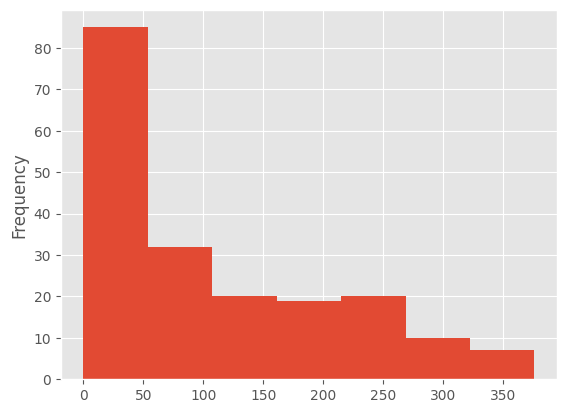

In [37]:
# Compare the above with histogram.
# About how many of the points above are in the groups 1-125, 125-250, and 250-376?

drinks['beer'].plot(kind='hist', bins=7);

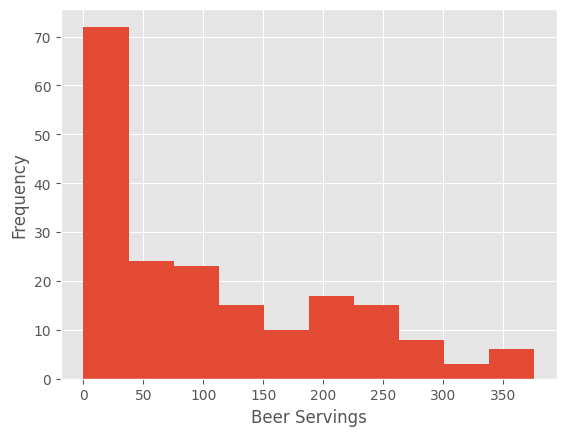

In [42]:
# Try more bins — it takes the range of the data and divides it into 20 evenly spaced bins.

drinks['beer'].plot(kind='hist', bins=10);
plt.xlabel('Beer Servings');
plt.ylabel('Frequency');

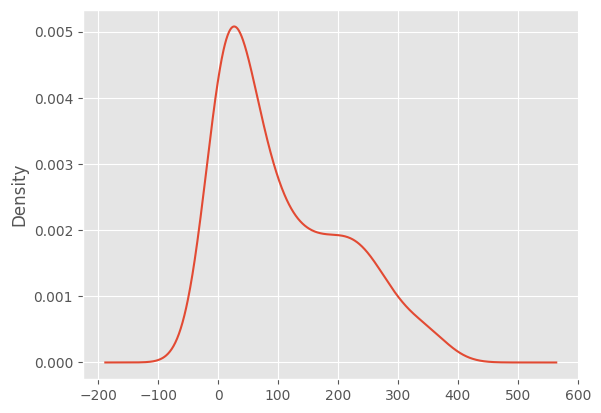

In [43]:
# Compare with density plot (smooth version of a histogram)

drinks['beer'].plot(kind='density');

In [30]:
# Making histograms of DataFrames — histogram of random data



### Single Histogram

In [44]:
norm = np.random.standard_normal(5000)

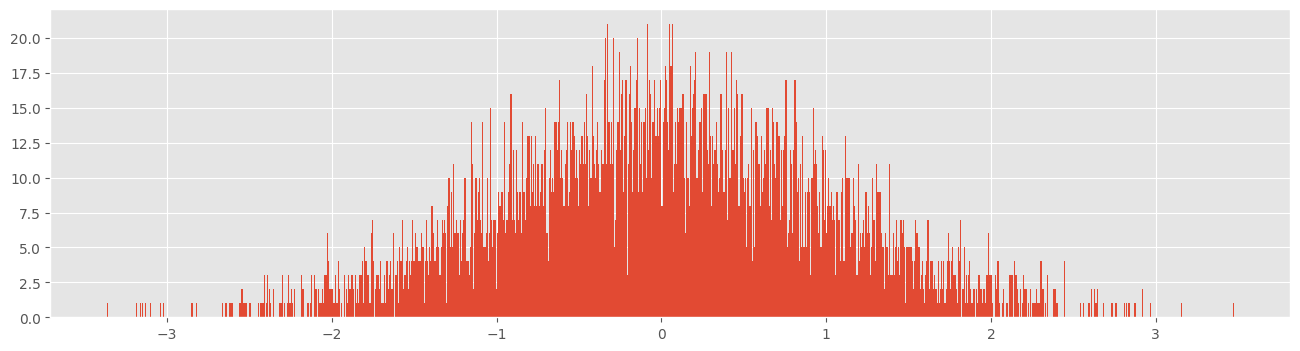

In [48]:
pd.Series(norm).hist(figsize=(16,4), bins=1000);

### Another bins example: Sometimes the binning makes the data look different or misleading.

### <font style='color: green'>Challenge: Create a histogram with pandas for using `sqft_living` in the housing data.</font>
- Set the bins to 20

<Axes: >

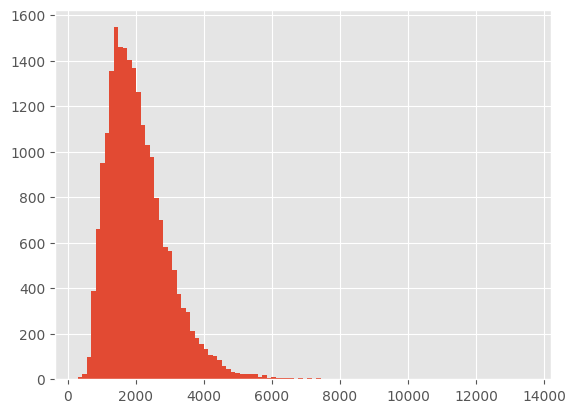

In [55]:
housing['sqft_living'].hist(bins=100)


In [56]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

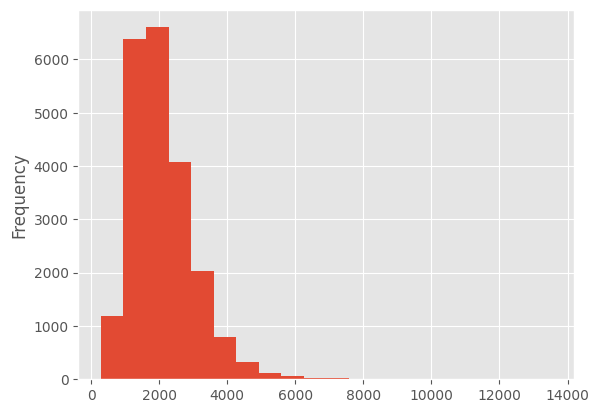

In [57]:
housing['sqft_living'].plot(kind='hist', bins=20);

In [58]:
housing['sqft_living'].sort_values().tail(10)

,sqft_living
1448,8000
1164,8010
18302,8020
14556,8670
4411,9200
8092,9640
9254,9890
3914,10040
7252,12050
12777,13540


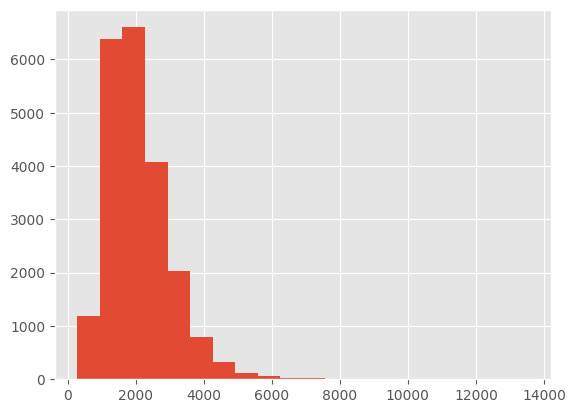

In [59]:
housing['sqft_living'].hist(bins=20);

<a id="grouped-histograms"></a>
### Grouped histograms: Show one histogram for each group.

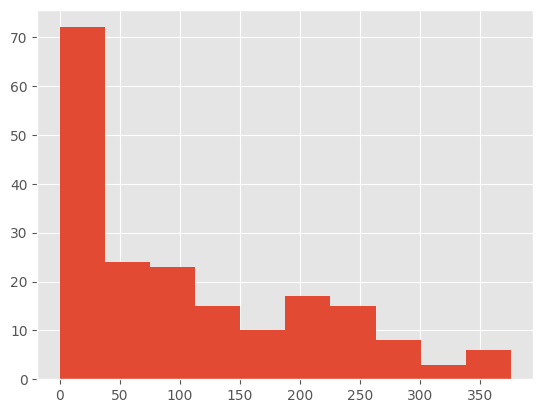

In [60]:
# Reminder: Overall histogram of beer servings

drinks['beer'].hist();

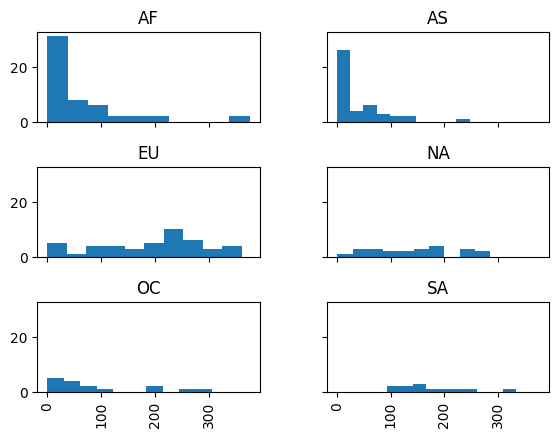

In [39]:
# Histogram of beer servings grouped by continent -- how might these graphs be misleading?

drinks.hist(by='continent',
            column='beer',
            sharex=True,
            sharey=True,
           layout=(3,2));

In [40]:
# Share the x- and y-axes


# <font style='color: blue'>d) Box Plots: Show quartiles (and outliers) for one or more numerical variables</font>
---

<img src="https://github.com/Ch3ddarr/DSB-Unit-02/blob/main/03%20-%20Data%20Visualisation/assets/boxplot.png?raw=1" style="width: 500px;">

We can use boxplots to quickly summarize distributions.

**Five-number summary:**

- min = minimum value
- 25% = first quartile (Q1) = median of the lower half of the data
- 50% = second quartile (Q2) = median of the data
- 75% = third quartile (Q3) = median of the upper half of the data
- max = maximum value

(It's more useful than mean and standard deviation for describing skewed distributions.)

**Interquartile Range (IQR)** = Q3 - Q1.  It's where 50% of the data sits.

**Outliers:**

- below Q1 - 1.5 * IQR
- above Q3 + 1.5 * IQR



In [61]:
df.describe()

,col1,col2,col3,col4
count,10.000000,10.000000,10.000000,10.000000
mean,-0.552352,-0.237221,-0.192725,0.052710
std,0.810389,1.033300,1.139542,1.060908
min,-1.593523,-2.346387,-2.680451,-1.816152
25%,-1.164542,-0.698719,-0.471212,0.091981
50%,-0.512239,-0.177645,0.124408,0.207970
75%,0.029411,0.371307,0.638956,0.377937
max,0.864435,1.051145,0.936378,1.996821


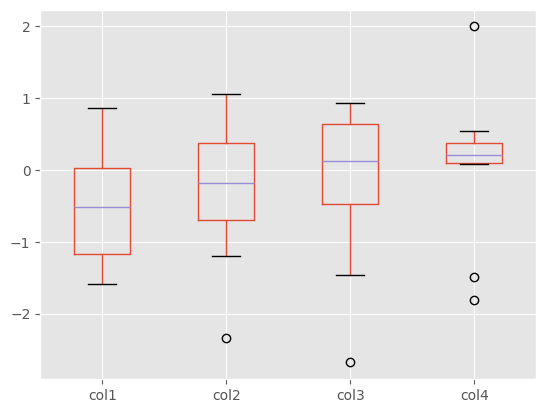

In [62]:
df.boxplot();

### Let's see how box plots are generated so we can best interpret them.

In [63]:
# Sort the spirit column


drinks['spirit'].sort_values().values

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   2,   2,   2,   2,   2,   2,   2,
         3,   3,   3,   3,   3,   3,   3,   3,   4,   4,   4,   5,   5,
         6,   6,   6,   7,   9,  11,  11,  12,  13,  15,  15,  16,  16,
        18,  18,  18,  18,  19,  21,  21,  22,  22,  25,  25,  27,  29,
        31,  31,  34,  35,  35,  35,  35,  38,  39,  41,  41,  42,  42,
        44,  46,  50,  51,  55,  56,  57,  60,  61,  63,  63,  65,  67,
        68,  69,  69,  69,  71,  71,  72,  74,  75,  76,  76,  79,  81,
        84,  87,  87,  88,  97,  97,  98,  98, 100, 100, 100, 100, 101,
       104, 104, 112, 114, 114, 114, 117, 117, 118, 118, 122, 122, 124,
       126, 128, 131, 132, 133, 133, 135, 137, 138, 145, 147, 151, 152,
       154, 156, 157, 158, 160, 170, 173, 173, 176, 178, 179, 186, 189,
       192, 194, 200, 202, 205, 215, 215, 216, 221, 226, 237, 24

In [64]:
# Show "five-number summary" for spirit

drinks['spirit'].describe()

,spirit
count,193.000000
mean,80.994819
std,88.284312
min,0.000000
25%,4.000000
50%,56.000000
75%,128.000000
max,438.000000


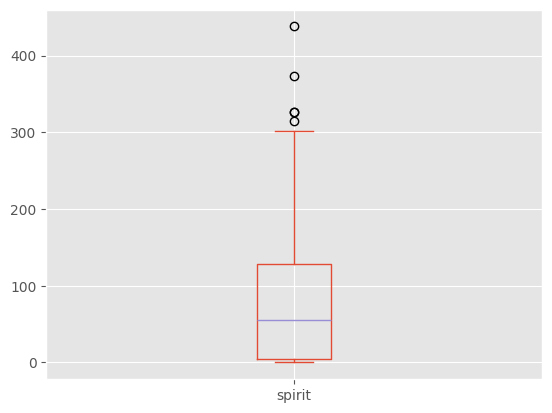

In [65]:
# Compare with box plot

drinks['spirit'].plot(kind='box');

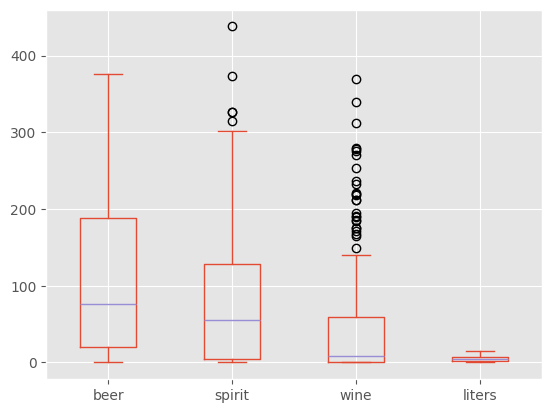

In [66]:
# Include multiple variables

drinks.plot(kind='box');

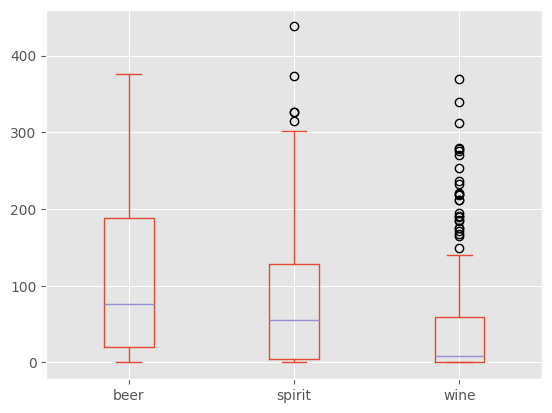

In [67]:
drinks.drop('liters', axis=1).plot(kind='box');

### How to use a box plot to preview the distributions in the housing data

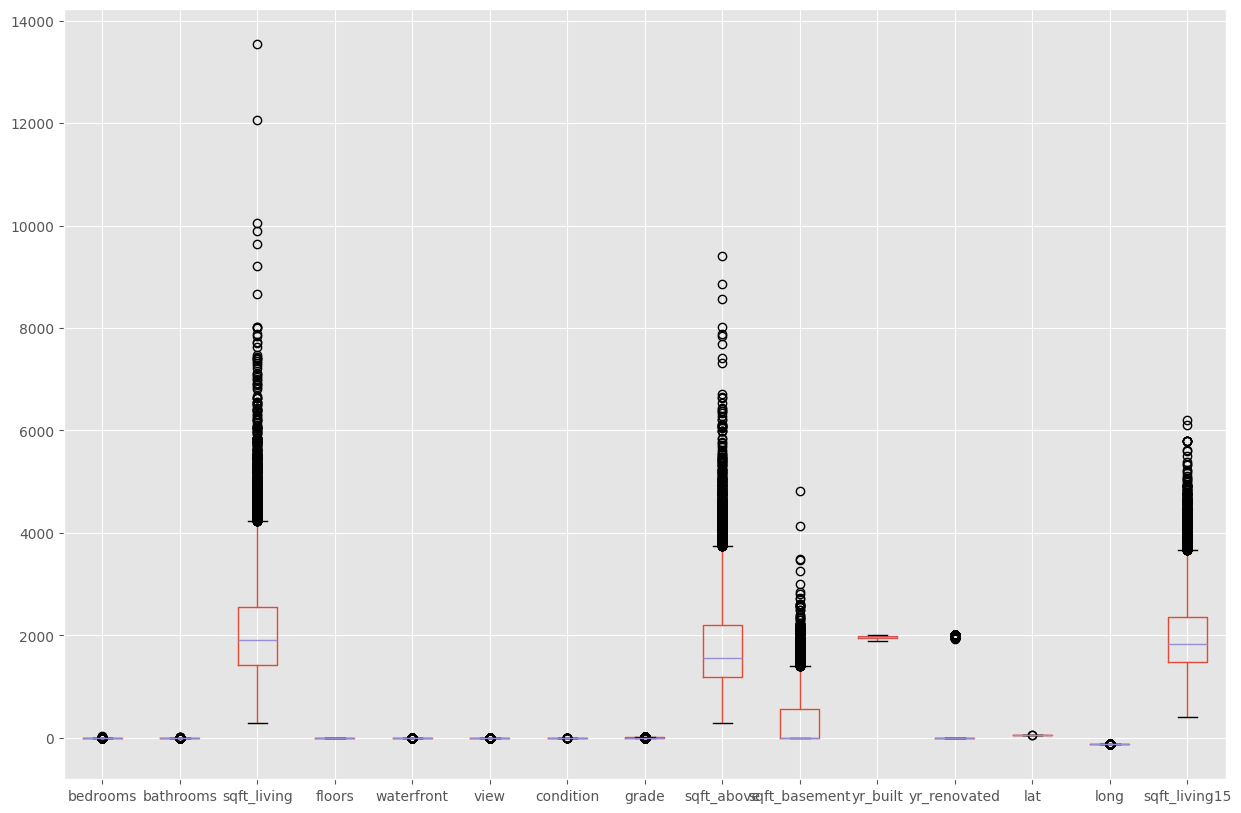

In [68]:
housing.drop(['id',
              'price',
              'sqft_lot',
              'sqft_lot15',
              'zipcode'], axis=1).boxplot(figsize=(15,10));

<a id="grouped-box-plots"></a>
### Grouped box plots: Show one box plot for each group.

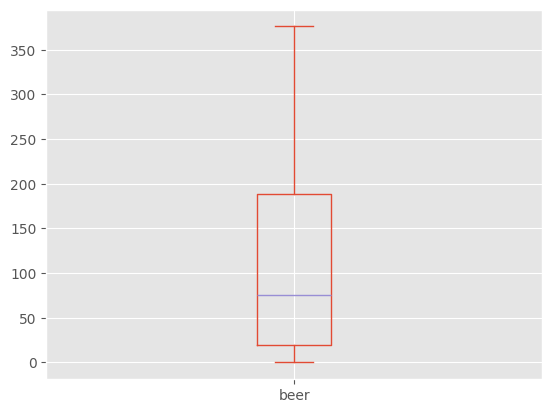

In [69]:
# Reminder: box plot of beer servings

drinks['beer'].plot(kind='box');

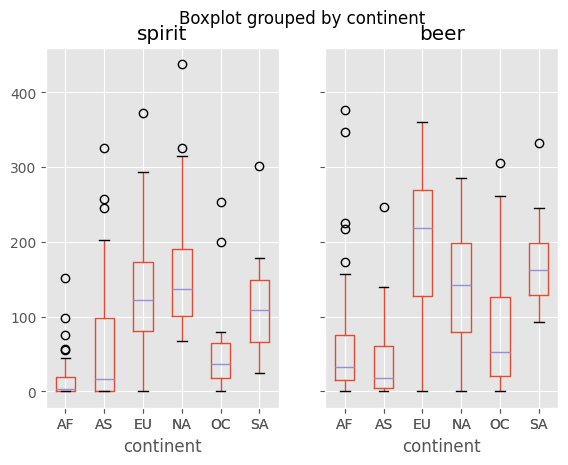

In [70]:
# Box plot of beer servings grouped by continent

drinks.boxplot(column=['spirit', 'beer'], by='continent');

# <font style='color: blue'>e) Scatter plots: Show the relationship between two numerical variables</font>
---


In [71]:
# Select the beer and wine columns and sort by beer

drinks[['beer', 'wine']].sort_values('beer').values

array([[  0,   0],
       [  0,   0],
       [  0,  74],
       [  0,   0],
       [  0,   0],
       [  0,   0],
       [  0,   0],
       [  0,   0],
       [  0,   0],
       [  0,   0],
       [  0,   0],
       [  0,   0],
       [  0,   0],
       [  0,   0],
       [  0,   0],
       [  1,   1],
       [  1,   1],
       [  1,   7],
       [  1,   4],
       [  2,   0],
       [  3,   1],
       [  5,   0],
       [  5,   0],
       [  5,   1],
       [  5,  16],
       [  5,   0],
       [  6,   1],
       [  6,   1],
       [  6,   0],
       [  6,   9],
       [  8,   1],
       [  8,   1],
       [  8,   0],
       [  9,   2],
       [  9,   0],
       [  9,   0],
       [  9,   7],
       [ 12,  10],
       [ 13,   0],
       [ 15,   3],
       [ 15,   1],
       [ 16,   5],
       [ 16,   0],
       [ 17,   1],
       [ 18,   0],
       [ 19,  32],
       [ 19,   2],
       [ 20,  31],
       [ 20,   0],
       [ 21,  11],
       [ 21,   5],
       [ 21,   1],
       [ 21,

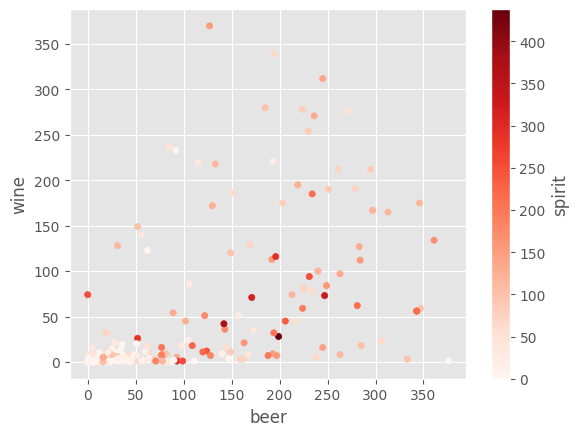

In [72]:
# Compare with scatter plot

drinks.plot(kind='scatter', x='beer', y='wine', c='spirit', colormap='Reds');

In [53]:
# Add transparency (great for plotting several graphs on top of each other, or for illustrating density!)


In [54]:
# Vary point color by spirit servings


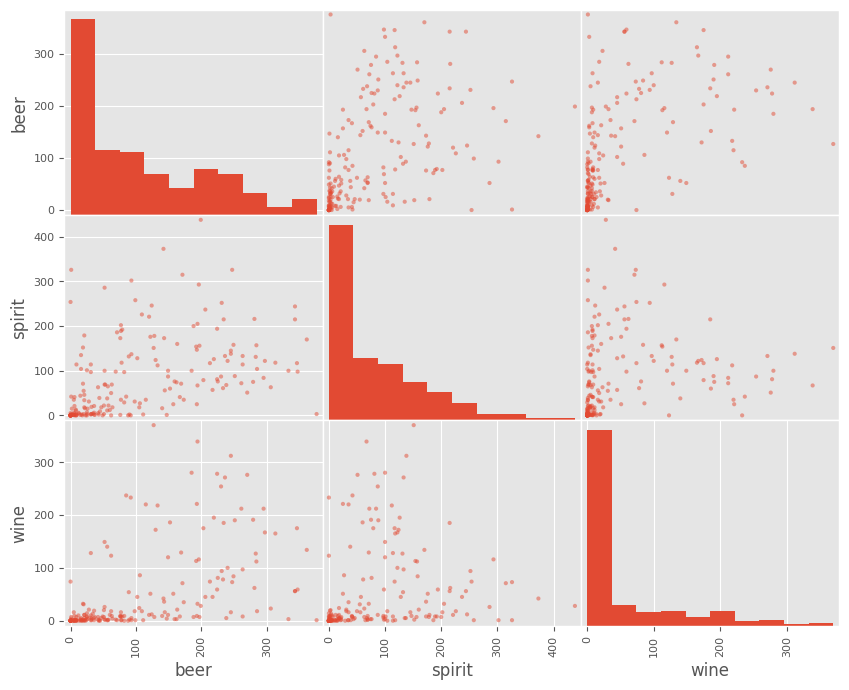

In [73]:
# Scatter matrix of three numerical columns

pd.plotting.scatter_matrix(drinks[['beer', 'spirit', 'wine']], figsize=(10, 8));

### Plotting `DataFrames`

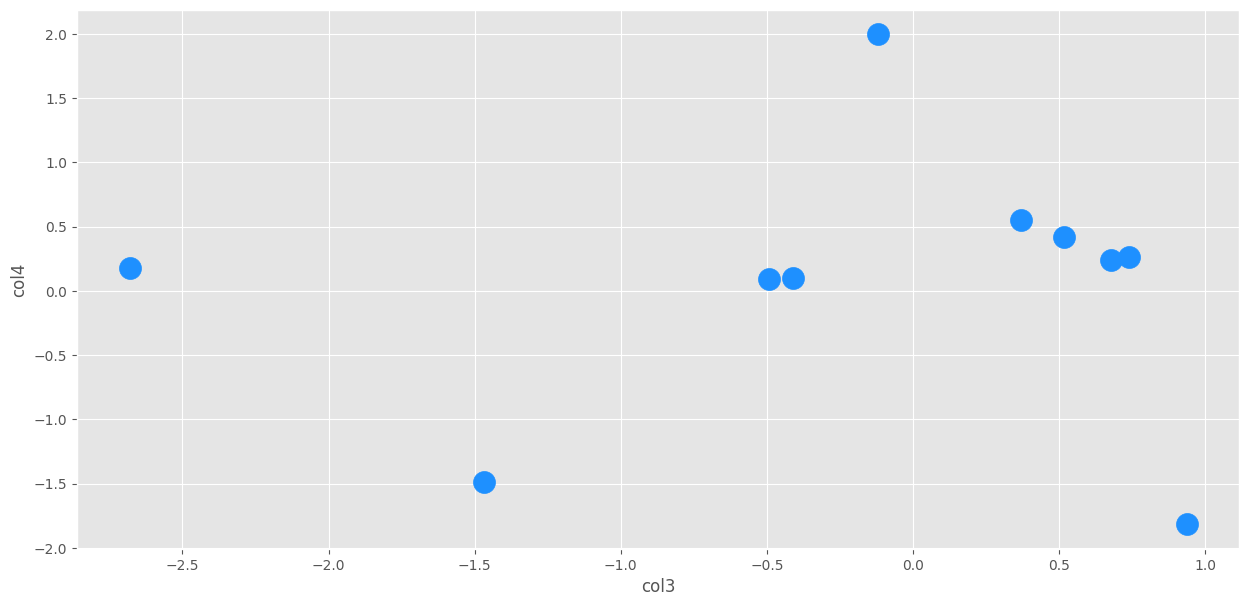

In [74]:
df.plot(kind='scatter',
        x='col3',
        y='col4',
        color='dodgerblue',
        figsize=(15,7),
        s=250);

### How to view the association between the variables `sqft_above` and `bathrooms` using a scatter plot

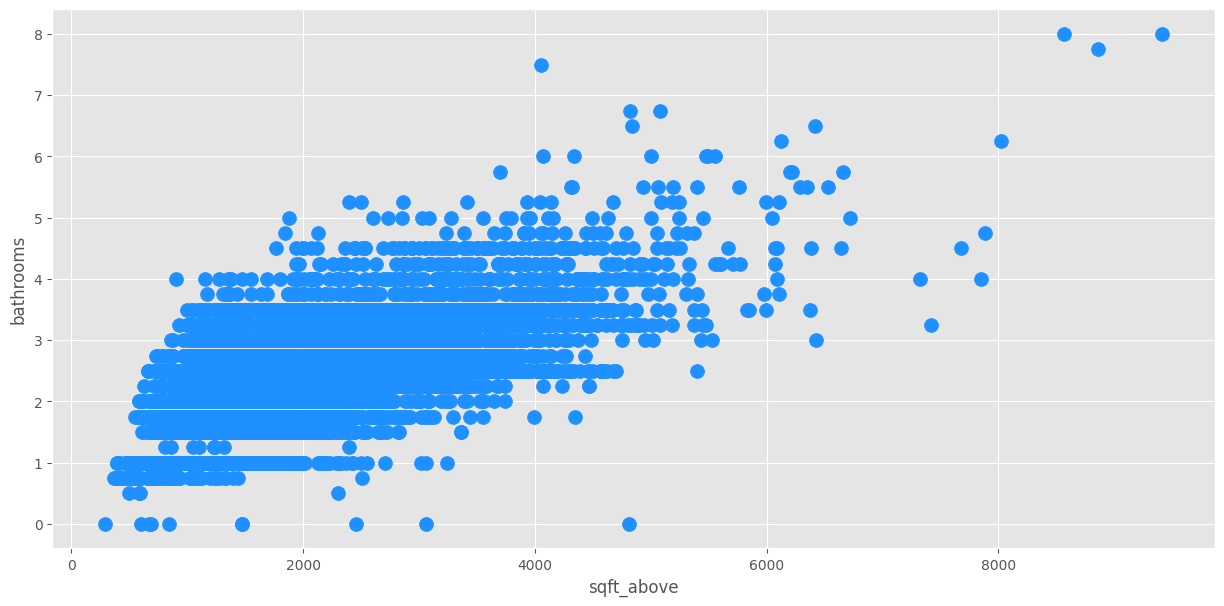

In [75]:
housing.plot(kind='scatter',
             x='sqft_above',
             y='bathrooms',
             color='dodgerblue',
             figsize=(15,7),
             s=100);

### How to use a list comprehension to change the size of the scatter plot dots based on `grade`

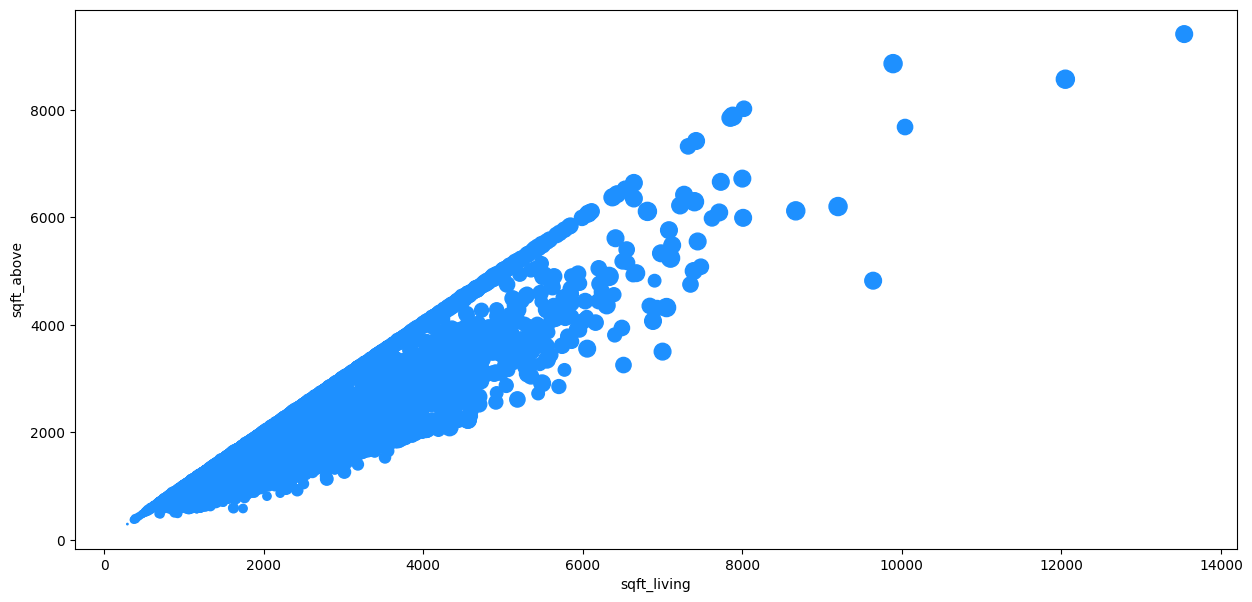

In [58]:
# This list comprehension sets the point sizes ('s') to be the square of the grade of the house (housing['grade'])

housing.plot(kind='scatter',
             x='sqft_living',
             y='sqft_above',
             color='dodgerblue',
             figsize=(15,7),
             s=[x**2 for x in housing['grade']]);

# <font style='color: blue'>f) Using Seaborn</font>

## Seaborn `pairplot`

---

- **Objective:** Know when to use Seaborn or advanced Matplotlib.

With the `DataFrame` object `housing`, we will render a pairplot using the Seaborn library.
What do each of the elements represent? Is this more or less useful than the previous plot?

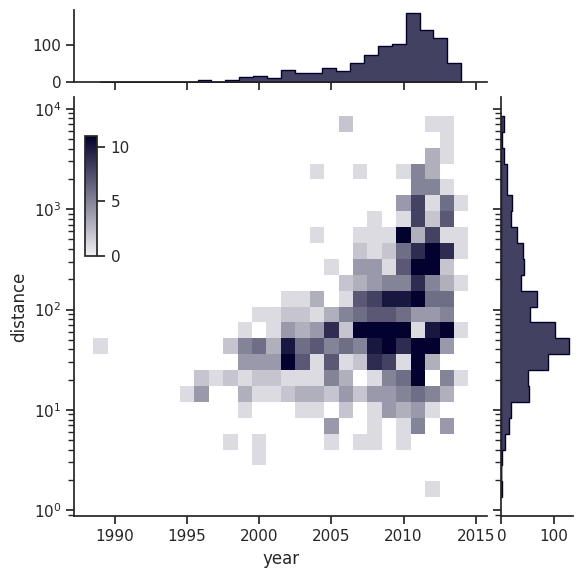

In [76]:
import seaborn as sns
sns.set_theme(style="ticks")

# Load the planets dataset and initialize the figure
planets = sns.load_dataset("planets")
g = sns.JointGrid(data=planets, x="year", y="distance", marginal_ticks=True)

# Set a log scaling on the y axis
g.ax_joint.set(yscale="log")

# Create an inset legend for the histogram colorbar
cax = g.figure.add_axes([.15, .55, .02, .2])

# Add the joint and marginal histogram plots
g.plot_joint(
    sns.histplot, discrete=(True, False),
    cmap="light:#03012d", pmax=.8, cbar=True, cbar_ax=cax
)
g.plot_marginals(sns.histplot, element="step", color="#03012d")

In [ ]:
sns.pairplot(housing);

**Answer:** _What do each of the elements represent?  Is this more or less useful than the previous plot?_
> In a pair plot we get to see every relationship between every _pair_ of variables.  We can see this is very useful for quickly discovering which variables have some kind of correlation during an exploratory data analysis.  However, when just looking at the `INDUS` feature, the pair plot is more difficult to read and interpret as opposed to the single histogram.  

## Seaborn `heatmap`
---

When you have too many variables, a pairplot or scatter matrix can become impossible to read. We can still gauge linear correlation using a heatmap of the correlation matrix.

In [61]:
housing.corr(numeric_only=True)

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,1.000000,-0.016762,0.001286,0.005160,-0.012258,-0.132109,0.018525,-0.002721,0.011592,-0.023783,0.008130,-0.010842,-0.005151,0.021380,-0.016907,-0.008224,-0.001891,0.020799,-0.002901,-0.138798
price,-0.016762,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.001286,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,0.005160,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,-0.012258,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,-0.132109,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.018525,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,-0.002721,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.011592,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,-0.023783,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406


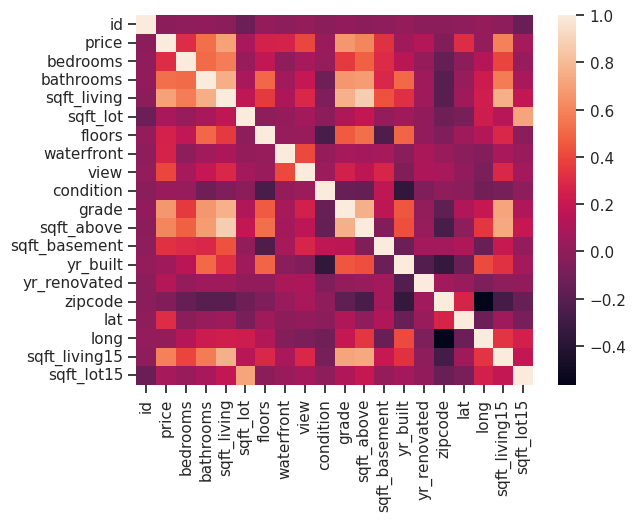

In [62]:
# Make a heatmap on the correlations between variables in the housing data:
housing_correlations = housing.corr(numeric_only=True);
sns.heatmap(housing_correlations);

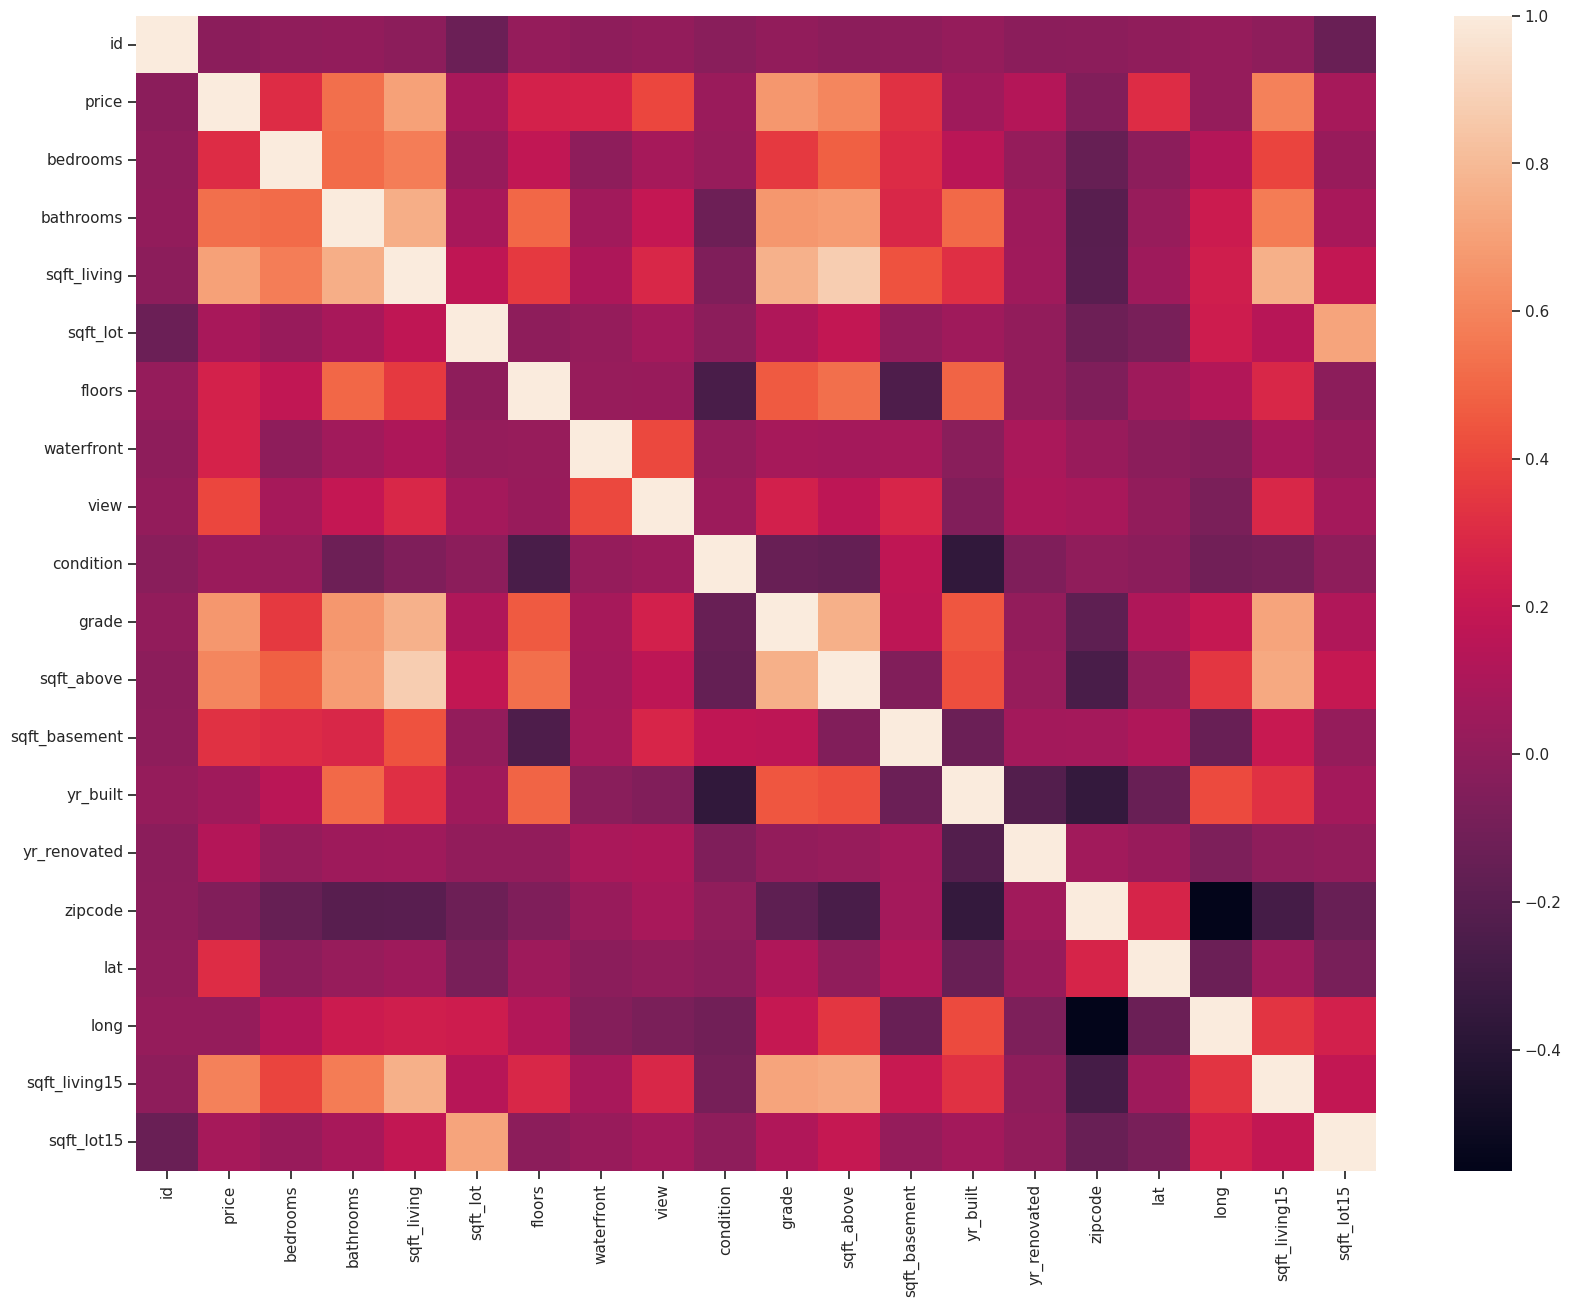

In [63]:
# to see the correlation heatmap in a bit more detail

# for this we need matplotlib.pyplot (see below for an explantion)

import matplotlib.pyplot as plt

plt.subplots(figsize=(20,15))
sns.heatmap(housing.corr(numeric_only=True));

In [64]:
# to see the correlations with just one variable e.g. the target ('price')

housing.corr(numeric_only=True)['price'].sort_values()

,price
zipcode,-0.053203
id,-0.016762
long,0.021626
condition,0.036362
yr_built,0.054012
sqft_lot15,0.082447
sqft_lot,0.089661
yr_renovated,0.126434
floors,0.256794
waterfront,0.266369


### <font style='color: green'>Challenge: Create a scatter plot of two heatmap entries that appear to have a very strong correlation (positive or negative).</font>

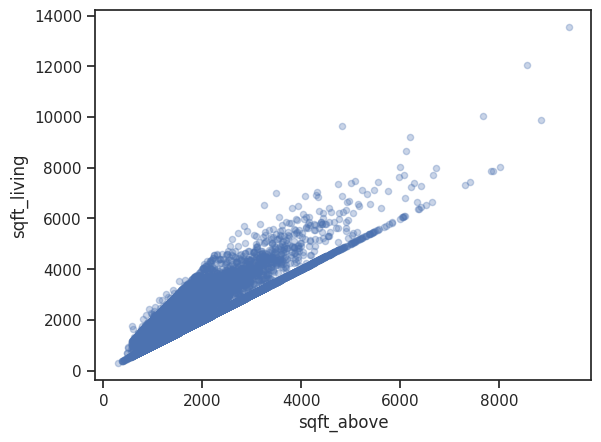

In [65]:
housing.plot(kind='scatter', x='sqft_above', y='sqft_living', alpha=0.3);

- Now, create a scatter plot of two heatmap entries that appear to have negative correlation.

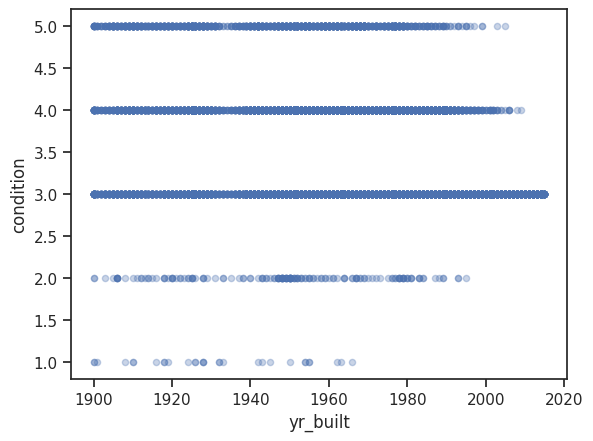

In [66]:
housing.plot(kind='scatter', x='yr_built', y='condition', alpha=0.3);

# <font style='color: blue'>g) A brief overview of Matplotlib (Figures, Subplots, and Axes)</font>

---

So far we have only used the visualization methods that come with pandas (albeit they are a wrapper for Matplotlib).  Let's explore how Matplotlib works, as it gives us much more functionality.

Matplotlib uses a blank canvas called a figure.  The figure is an instance of the class `plt.Figure` and can be thought of as a single container that contains all the objects representing axes, graphics, text, and labels.

The axes (an instance of the class `plt.Axes`) is a bounding box with ticks and labels, which will eventually contain the plot elements that make up our visualization. We'll commonly use the variable name `fig` to refer to a figure instance, and `ax` to refer to an axes instance or group of axes instances. Once we have created an axes, we can use the `ax.plot` function to plot some data.

In [67]:
# instantiate an instance of the plt.Figure class, and plot 3 ax objects

fig = plt.figure()


<Figure size 640x480 with 0 Axes>

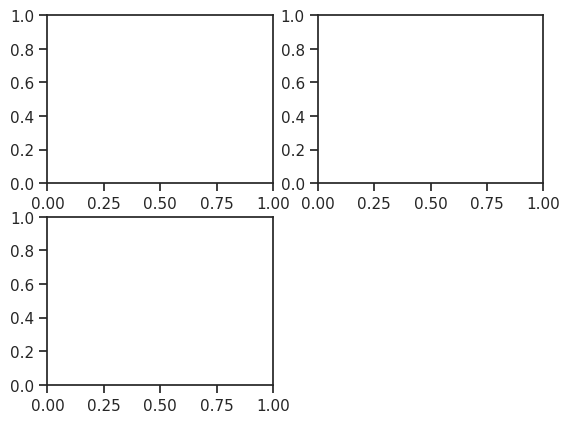

In [68]:
# add a histogram to the first ax

# note: you have to put all plotting commands in one cell, as the plots are reset after each cell
# cell is run


fig = plt.figure()

ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)
ax3 = fig.add_subplot(2,2,3)


To make it easier to create a grid of graphs, Matplotlib provides the `.subplots()` method to instantiate Fig and Axes, and return a Fig object and Axes objects as a numpy array.

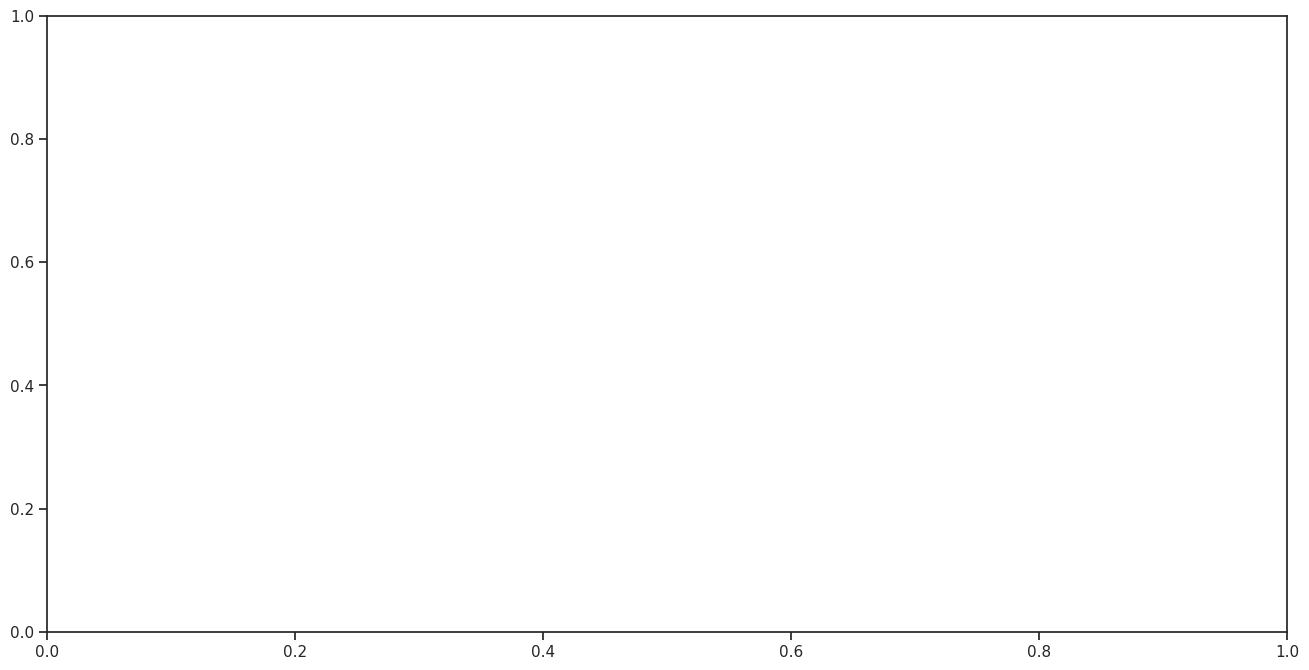

In [69]:
# create one graph

fig = plt.subplots(1,1, figsize=(16,8));

In [70]:
# create a grid with 6 graphs


pandas allows us to plot to a specified axes if we pass the object to the ax parameter.

In [ ]:
fig, axes = plt.subplots(2,3, figsize=(16,8))
df.plot(ax=axes[0][0]);
df['col1'].plot(ax=axes[0][1]);
df['col2'].plot(ax=axes[1][1]);

## Let's use a bit more customization.
---

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(16,8))

# We can change the ticks' size.
df['col2'].plot(figsize=(16,4), color='purple', fontsize=10, ax=axes[0][0])

# We can also change which ticks are visible.
# Let's show only the even ticks. ('idx % 2 == 0' only if 'idx' is even.)
ticks_to_show = [idx for idx, _ in enumerate(df['col2'].index) if idx % 2 == 0]
df['col2'].plot(figsize=(16,4),
                color='purple',
                xticks=ticks_to_show,
                fontsize=10,
                ax=axes[0][1])

# We can change the label rotation.
df.plot(figsize=(15,7),
        title='Big Rotated Labels - Tiny Title',
        fontsize=10,
        rot=-50,
        ax=axes[1][0])

# We have to use ".set_title()" to fix title size.
df.plot(figsize=(16,8),
        fontsize=10,
        rot=-50,
        ax=axes[1][1])\
       .set_title('Better-Sized Title', fontsize=21, y=1.01);

# <font style='color: blue'>h) Additional Topics</font>

In [ ]:
# Saving a plot to a file
drinks['beer'].plot(kind='hist', bins=20, title='Histogram of Beer Servings');
plt.xlabel('Beer Servings');
plt.ylabel('Frequency');
plt.savefig('beer_histogram.png');    # Save to file!

In [ ]:
# List available plot styles
plt.style.available

In [ ]:
# Change to a different style.
plt.style.use('ggplot')

# <font style='color: blue'>Summary</font>

In this lab, we showed examples how to create a variety of plots using pandas and Matplotlib. We also showed how to use each plot to effectively display data.

Do not be concerned if you do not remember everything — this will come with practice! Although there are many plot styles, many similarities exist between how each plot is drawn. For example, they have most parameters in common, and the same Matplotlib functions are used to modify the plot area.

We looked at:
- Line plots
- Bar plots
- Histograms
- Box plots
- Special seaborn plots
- How Matplotlib works

#### Reference (bookmark this!):
- [Matplotlib colors](https://matplotlib.org/stable/gallery/color/named_colors.html)
- [Matplotlib linestyles](https://matplotlib.org/stable/gallery/lines_bars_and_markers/linestyles.html)